# CENG 476 – Deep Learning Project
## Cats vs Dogs Binary Image Classification

This notebook implements the project requirements from the assignment:
- Transfer learning with ResNet18
- Batch Normalization
- Dropout
- Data augmentation and weight decay
- AdamW optimizer
- Learning-rate scheduling
- Early stopping
- Train/validation/test evaluation
- Baseline vs improved model comparison
- Accuracy, precision, recall, F1-score
- Confusion matrix and training curves
- Reproducible experiments

**Important:** Do not invent final performance values. Run the notebook on the dataset and use the generated results in the report.


## 1. Dataset

This project uses the Kaggle **Dogs vs Cats** dataset. The original competition training archive contains 25,000 labeled cat/dog images.

Expected options:
1. A folder containing files such as `cat.0.jpg`, `dog.0.jpg`, ...
2. A folder structure such as:
   - `train/cats`
   - `train/dogs`

The notebook automatically downloads, extracts, cleans, and indexes the dataset when run in Google Colab.


In [3]:
# If needed, install packages in your environment:
# !pip install torch torchvision scikit-learn matplotlib seaborn pillow pandas

import os
import copy
import random
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import ReduceLROnPlateau
from torch.utils.data import Dataset, DataLoader, Subset
from torchvision import transforms, models
from PIL import Image

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report
)

SEED = 42

def set_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed()

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)


Device: cuda


In [4]:
# ============================================================
# AUTOMATIC DATASET SETUP (Google Colab)
# ============================================================
# You do NOT need to upload the ~800 MB dataset manually.
# Run this cell in Google Colab and it will download/extract it.

from pathlib import Path
import os, zipfile, urllib.request

ZIP_PATH = Path("/content/kagglecatsanddogs_5340.zip")
EXTRACT_DIR = Path("/content/catsdogs")
DATA_DIR = EXTRACT_DIR / "PetImages"

DATA_URL = (
    "https://download.microsoft.com/download/3/E/1/"
    "3E1C3F21-ECDB-4869-8368-6DEBA77B919F/"
    "kagglecatsanddogs_5340.zip"
)

if not DATA_DIR.exists():
    if not ZIP_PATH.exists():
        print("Downloading Cats vs Dogs dataset...")
        urllib.request.urlretrieve(DATA_URL, ZIP_PATH)
        print("Download complete.")

    print("Extracting dataset...")
    with zipfile.ZipFile(ZIP_PATH, "r") as z:
        z.extractall(EXTRACT_DIR)
    print("Extraction complete.")

print("Dataset directory:", DATA_DIR)


Download complete.
Extracting dataset...
Extraction complete.
Dataset directory: /content/catsdogs/PetImages


In [5]:
# Remove corrupted images before training.
# The original Cats vs Dogs dataset contains a small number of invalid files.

from PIL import Image
from pathlib import Path

bad_files = []

for p in DATA_DIR.rglob("*"):
    if p.is_file() and p.suffix.lower() in {".jpg", ".jpeg", ".png", ".bmp", ".webp"}:
        try:
            with Image.open(p) as im:
                im.verify()
        except Exception:
            bad_files.append(p)

for p in bad_files:
    try:
        p.unlink()
    except Exception:
        pass

print(f"Removed {len(bad_files)} corrupted image(s).")


/usr/local/lib/python3.13/dist-packages/PIL/TiffImagePlugin.py:950: UserWarning: Truncated File Read
  warnings.warn(str(msg))


Removed 2 corrupted image(s).


In [6]:
# Index the dataset and create labels.
# Cat = 0, Dog = 1

IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

def collect_images(root):
    root = Path(root)
    records = []

    for p in root.rglob("*"):
        if not p.is_file() or p.suffix.lower() not in IMAGE_EXTENSIONS:
            continue

        parts = {x.lower() for x in p.parts}
        name = p.stem.lower()

        if "cat" in parts or "cats" in parts or name.startswith("cat."):
            label = 0
        elif "dog" in parts or "dogs" in parts or name.startswith("dog."):
            label = 1
        else:
            continue

        records.append((str(p), label))

    return pd.DataFrame(records, columns=["path", "label"]).drop_duplicates("path")

df = collect_images(DATA_DIR)

if len(df) == 0:
    raise RuntimeError(
        "No labeled images were found. Make sure the dataset download/extraction cell completed successfully."
    )

print("Total images:", len(df))
print("Cats:", int((df["label"] == 0).sum()))
print("Dogs:", int((df["label"] == 1).sum()))
print(df.head())


Total images: 24998
Cats: 12499
Dogs: 12499
                                        path  label
0   /content/catsdogs/PetImages/Cat/7451.jpg      0
1    /content/catsdogs/PetImages/Cat/583.jpg      0
2  /content/catsdogs/PetImages/Cat/12444.jpg      0
3   /content/catsdogs/PetImages/Cat/9764.jpg      0
4   /content/catsdogs/PetImages/Cat/9975.jpg      0


## 2. Train / Validation / Test Split

We use a stratified split so the cat/dog class ratio remains approximately equal:
- 70% training
- 15% validation
- 15% test

The test set is kept separate until final evaluation.


In [7]:
train_df, temp_df = train_test_split(
    df, test_size=0.30, stratify=df["label"], random_state=SEED
)

val_df, test_df = train_test_split(
    temp_df, test_size=0.50, stratify=temp_df["label"], random_state=SEED
)

train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print(f"Train: {len(train_df)}")
print(f"Validation: {len(val_df)}")
print(f"Test: {len(test_df)}")
print()
print("Train distribution:")
print(train_df["label"].value_counts(normalize=True))


Train: 17498
Validation: 3750
Test: 3750

Train distribution:
label
1    0.5
0    0.5
Name: proportion, dtype: float64


In [8]:
IMG_SIZE = 224
BATCH_SIZE = 32
NUM_WORKERS = 2

# ImageNet normalization is used because ResNet18 is initialized from ImageNet weights.
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(12),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

eval_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

class CatsDogsDataset(Dataset):
    def __init__(self, frame, transform=None):
        self.frame = frame.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.frame)

    def __getitem__(self, idx):
        row = self.frame.iloc[idx]
        image = Image.open(row["path"]).convert("RGB")
        label = int(row["label"])

        if self.transform:
            image = self.transform(image)

        return image, label

train_ds = CatsDogsDataset(train_df, train_transform)
val_ds = CatsDogsDataset(val_df, eval_transform)
test_ds = CatsDogsDataset(test_df, eval_transform)

train_loader = DataLoader(
    train_ds, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=NUM_WORKERS, pin_memory=torch.cuda.is_available()
)
val_loader = DataLoader(
    val_ds, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=torch.cuda.is_available()
)
test_loader = DataLoader(
    test_ds, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=torch.cuda.is_available()
)

print("DataLoaders ready.")


DataLoaders ready.


## 3. Model Architecture

### Improved model

A pretrained ResNet18 is used as the convolutional feature extractor. Its final classification layer is replaced with a custom binary-classification head:

**ResNet18 → Linear → BatchNorm1d → ReLU → Dropout → Linear(2)**

This satisfies the assignment's requirement to explicitly design and justify the model rather than simply using an unchanged pretrained classifier.

- Input: `3 × 224 × 224`
- Output: 2 logits (`cat`, `dog`)
- Batch Normalization: in the custom classification head
- Dropout: 0.50
- Weight decay (L2-style regularization): 1e-4


In [9]:
def build_model(dropout=0.50, pretrained=True):
    weights = models.ResNet18_Weights.DEFAULT if pretrained else None
    model = models.resnet18(weights=weights)

    num_features = model.fc.in_features

    # Custom classification head
    model.fc = nn.Sequential(
        nn.Linear(num_features, 256),
        nn.BatchNorm1d(256),
        nn.ReLU(inplace=True),
        nn.Dropout(dropout),
        nn.Linear(256, 2)
    )
    return model

model = build_model().to(DEVICE)
print(model)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 173MB/s]


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

## 4. Baseline Model

The baseline is a pretrained ResNet18 with only its final layer replaced by a 2-class classifier. This gives us a meaningful comparison against the improved model with BatchNorm, Dropout, augmentation, weight decay, scheduler and early stopping.


In [10]:
def build_baseline(pretrained=True):
    weights = models.ResNet18_Weights.DEFAULT if pretrained else None
    model = models.resnet18(weights=weights)
    model.fc = nn.Linear(model.fc.in_features, 2)
    return model.to(DEVICE)


## 5. Training Utilities

Early stopping monitors validation loss. If validation loss does not improve for `patience` consecutive epochs, training stops and the best model weights are restored.

`ReduceLROnPlateau` reduces the learning rate when validation loss stops improving.


In [11]:
def run_epoch(model, loader, criterion, optimizer=None):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()

    total_loss = 0.0
    all_preds, all_labels = [], []

    for images, labels in loader:
        images = images.to(DEVICE, non_blocking=True)
        labels = labels.to(DEVICE, non_blocking=True)

        if is_train:
            optimizer.zero_grad(set_to_none=True)

        with torch.set_grad_enabled(is_train):
            outputs = model(images)
            loss = criterion(outputs, labels)
            preds = outputs.argmax(dim=1)

            if is_train:
                loss.backward()
                optimizer.step()

        total_loss += loss.item() * images.size(0)
        all_preds.extend(preds.detach().cpu().numpy())
        all_labels.extend(labels.detach().cpu().numpy())

    avg_loss = total_loss / len(loader.dataset)
    acc = accuracy_score(all_labels, all_preds)
    return avg_loss, acc


def train_model(
    model,
    train_loader,
    val_loader,
    epochs=15,
    lr=1e-4,
    weight_decay=1e-4,
    patience=4
):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.AdamW(
        model.parameters(),
        lr=lr,
        weight_decay=weight_decay
    )
    scheduler = ReduceLROnPlateau(
        optimizer,
        mode="min",
        factor=0.5,
        patience=1
    )

    history = {
        "train_loss": [], "val_loss": [],
        "train_acc": [], "val_acc": [],
        "lr": []
    }

    best_state = copy.deepcopy(model.state_dict())
    best_val_loss = float("inf")
    bad_epochs = 0

    for epoch in range(1, epochs + 1):
        start = time.time()

        train_loss, train_acc = run_epoch(
            model, train_loader, criterion, optimizer
        )
        val_loss, val_acc = run_epoch(
            model, val_loader, criterion
        )

        scheduler.step(val_loss)
        current_lr = optimizer.param_groups[0]["lr"]

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)
        history["lr"].append(current_lr)

        print(
            f"Epoch {epoch:02d}/{epochs} | "
            f"train loss {train_loss:.4f} acc {train_acc:.4f} | "
            f"val loss {val_loss:.4f} acc {val_acc:.4f} | "
            f"lr {current_lr:.2e} | "
            f"{time.time()-start:.1f}s"
        )

        if val_loss < best_val_loss - 1e-4:
            best_val_loss = val_loss
            best_state = copy.deepcopy(model.state_dict())
            bad_epochs = 0
        else:
            bad_epochs += 1
            if bad_epochs >= patience:
                print("Early stopping triggered.")
                break

    model.load_state_dict(best_state)
    return model, history


In [12]:
def evaluate_model(model, loader):
    model.eval()
    all_preds, all_labels = [], []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(DEVICE)
            outputs = model(images)
            preds = outputs.argmax(dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.numpy())

    metrics = {
        "Accuracy": accuracy_score(all_labels, all_preds),
        "Precision": precision_score(all_labels, all_preds, zero_division=0),
        "Recall": recall_score(all_labels, all_preds, zero_division=0),
        "F1": f1_score(all_labels, all_preds, zero_division=0),
    }

    return metrics, np.array(all_labels), np.array(all_preds)

def plot_history(history, title):
    epochs = range(1, len(history["train_loss"]) + 1)

    plt.figure(figsize=(7, 5))
    plt.plot(epochs, history["train_loss"], label="Train Loss")
    plt.plot(epochs, history["val_loss"], label="Validation Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(title + " – Loss")
    plt.legend()
    plt.grid(True)
    plt.show()

    plt.figure(figsize=(7, 5))
    plt.plot(epochs, history["train_acc"], label="Train Accuracy")
    plt.plot(epochs, history["val_acc"], label="Validation Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title(title + " – Accuracy")
    plt.legend()
    plt.grid(True)
    plt.show()

    plt.figure(figsize=(7, 5))
    plt.plot(epochs, history["lr"], marker="o")
    plt.xlabel("Epoch")
    plt.ylabel("Learning Rate")
    plt.title(title + " – Learning Rate")
    plt.yscale("log")
    plt.grid(True)
    plt.show()

def plot_confusion(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(
        cm, annot=True, fmt="d", cmap="Blues",
        xticklabels=["Cat", "Dog"],
        yticklabels=["Cat", "Dog"]
    )
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title(title)
    plt.show()


## 6. Experiment A – Baseline

Run the baseline first. Keep the printed results because they will be used in the Results and Discussion section.


/usr/local/lib/python3.13/dist-packages/PIL/TiffImagePlugin.py:950: UserWarning: Truncated File Read
  warnings.warn(str(msg))


Epoch 01/10 | train loss 0.0760 acc 0.9712 | val loss 0.0425 acc 0.9861 | lr 1.00e-04 | 120.7s


/usr/local/lib/python3.13/dist-packages/PIL/TiffImagePlugin.py:950: UserWarning: Truncated File Read
  warnings.warn(str(msg))


Epoch 02/10 | train loss 0.0435 acc 0.9843 | val loss 0.0339 acc 0.9867 | lr 1.00e-04 | 118.9s


/usr/local/lib/python3.13/dist-packages/PIL/TiffImagePlugin.py:950: UserWarning: Truncated File Read
  warnings.warn(str(msg))


...

Epoch 07/10 | train loss 0.0074 acc 0.9978 | val loss 0.0293 acc 0.9904 | lr 5.00e-05 | 120.1s


/usr/local/lib/python3.13/dist-packages/PIL/TiffImagePlugin.py:950: UserWarning: Truncated File Read
  warnings.warn(str(msg))


Epoch 08/10 | train loss 0.0068 acc 0.9983 | val loss 0.0307 acc 0.9909 | lr 2.50e-05 | 119.8s


/usr/local/lib/python3.13/dist-packages/PIL/TiffImagePlugin.py:950: UserWarning: Truncated File Read
  warnings.warn(str(msg))


Epoch 09/10 | train loss 0.0048 acc 0.9983 | val loss 0.0324 acc 0.9936 | lr 2.50e-05 | 120.9s
Early stopping triggered.


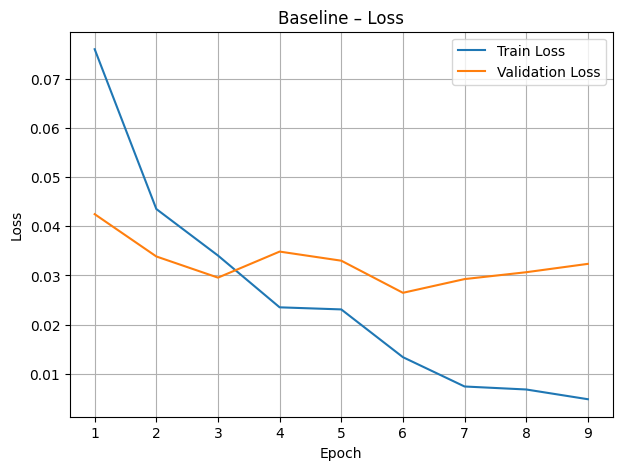

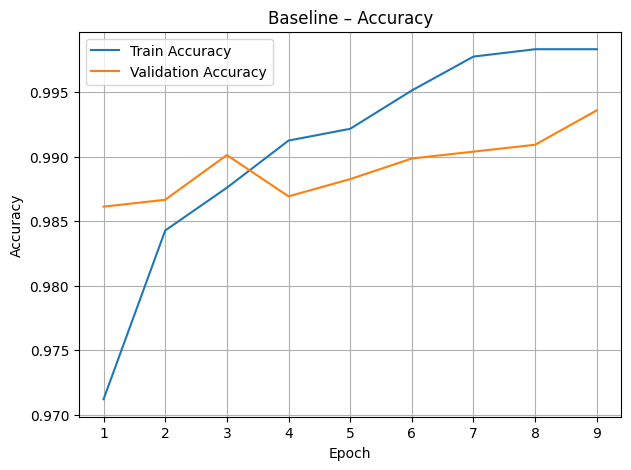

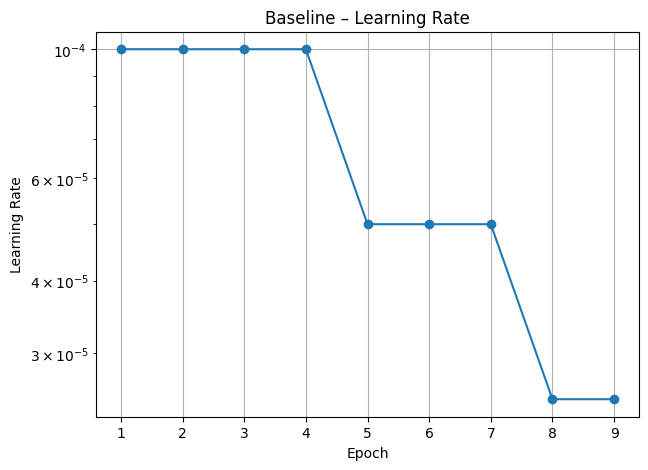

Accuracy     0.984533
Precision    0.982988
Recall       0.986133
F1           0.984558
dtype: float64


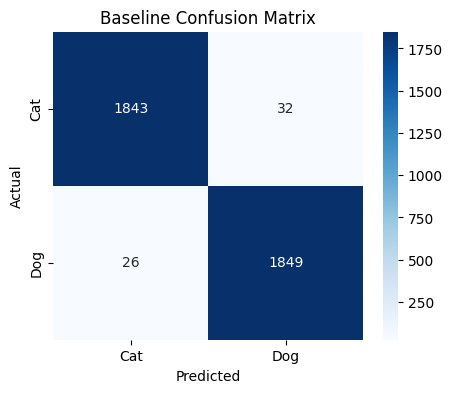

In [13]:
# Baseline training
baseline = build_baseline()
baseline, baseline_history = train_model(
    baseline,
    train_loader,
    val_loader,
    epochs=10,
    lr=1e-4,
    weight_decay=0.0,
    patience=3
)

plot_history(baseline_history, "Baseline")

baseline_metrics, baseline_y, baseline_pred = evaluate_model(
    baseline, test_loader
)
print(pd.Series(baseline_metrics))
plot_confusion(baseline_y, baseline_pred, "Baseline Confusion Matrix")


## 7. Experiment B – Improved Model

The improved model adds:
- Batch Normalization
- Dropout
- Data augmentation
- AdamW weight decay
- ReduceLROnPlateau scheduler
- Early stopping

These modifications directly address the assignment's regularization and optimization requirements.


Model device: cuda:0


/usr/local/lib/python3.13/dist-packages/PIL/TiffImagePlugin.py:950: UserWarning: Truncated File Read
  warnings.warn(str(msg))


Epoch 01/15 | train loss 0.0864 acc 0.9667 | val loss 0.0357 acc 0.9896 | lr 1.00e-04 | 121.4s


/usr/local/lib/python3.13/dist-packages/PIL/TiffImagePlugin.py:950: UserWarning: Truncated File Read
  warnings.warn(str(msg))


Epoch 02/15 | train loss 0.0471 acc 0.9836 | val loss 0.0416 acc 0.9859 | lr 1.00e-04 | 122.6s


...

Epoch 05/15 | train loss 0.0293 acc 0.9898 | val loss 0.0403 acc 0.9851 | lr 5.00e-05 | 121.1s


/usr/local/lib/python3.13/dist-packages/PIL/TiffImagePlugin.py:950: UserWarning: Truncated File Read
  warnings.warn(str(msg))


Epoch 06/15 | train loss 0.0135 acc 0.9959 | val loss 0.0319 acc 0.9885 | lr 5.00e-05 | 119.7s


/usr/local/lib/python3.13/dist-packages/PIL/TiffImagePlugin.py:950: UserWarning: Truncated File Read
  warnings.warn(str(msg))


Epoch 07/15 | train loss 0.0101 acc 0.9968 | val loss 0.0320 acc 0.9893 | lr 2.50e-05 | 119.5s
Early stopping triggered.


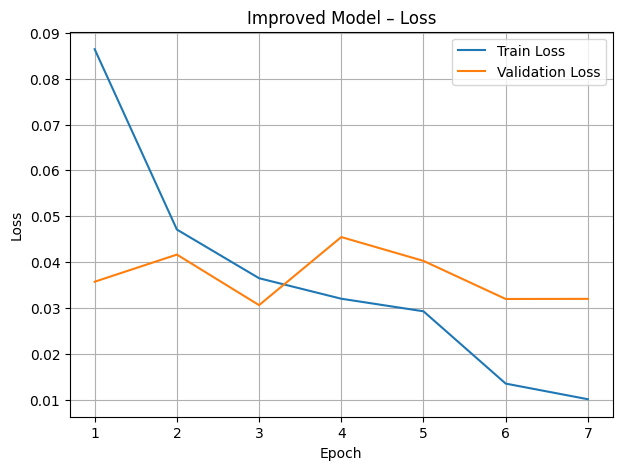

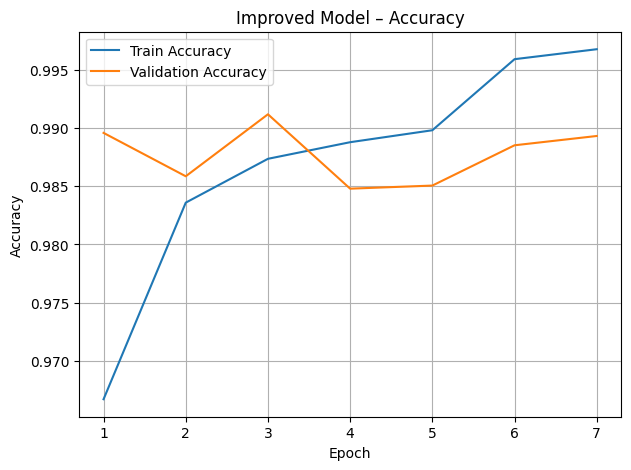

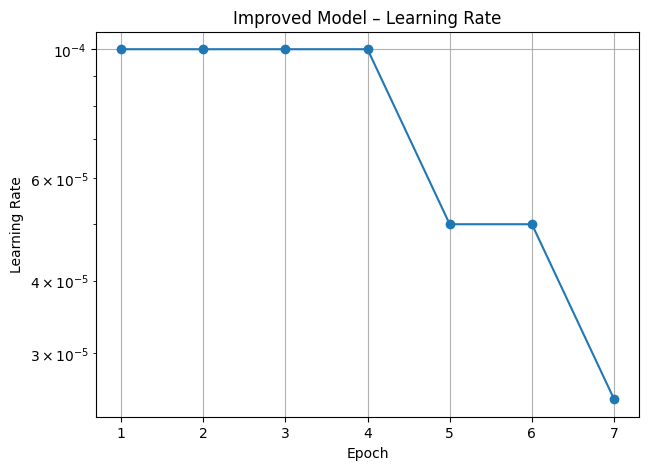

Accuracy     0.987467
Precision    0.988248
Recall       0.986667
F1           0.987457
dtype: float64


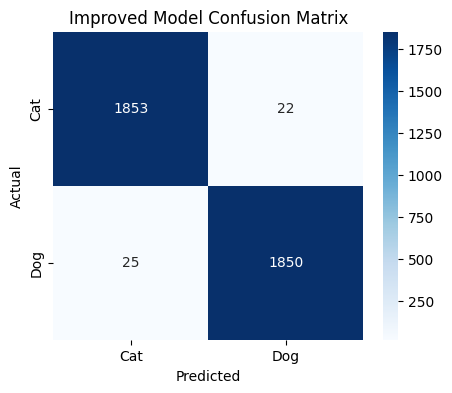


Classification report:
              precision    recall  f1-score   support

         Cat     0.9867    0.9883    0.9875      1875
         Dog     0.9882    0.9867    0.9875      1875

    accuracy                         0.9875      3750
   macro avg     0.9875    0.9875    0.9875      3750
weighted avg     0.9875    0.9875    0.9875      3750



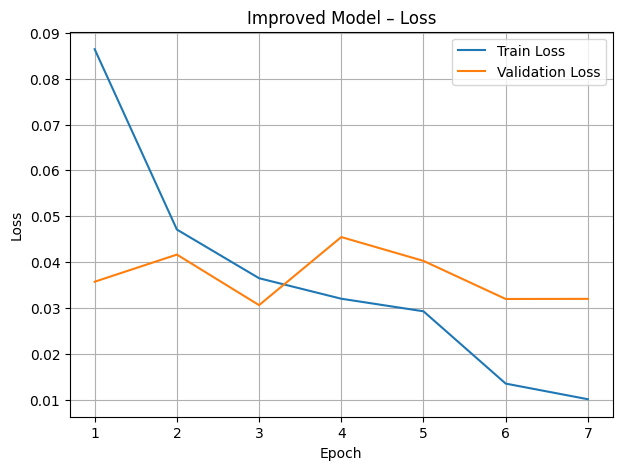

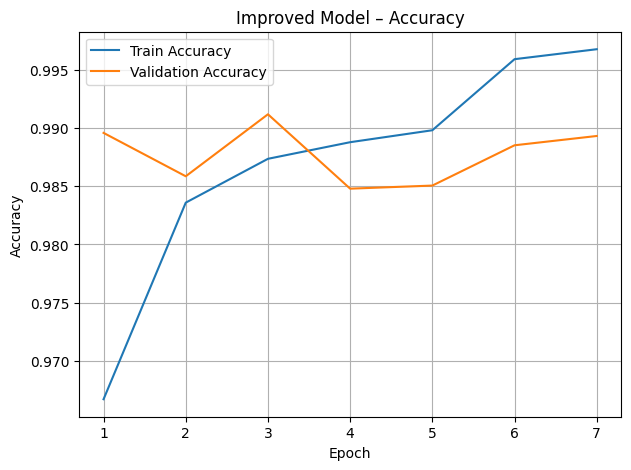

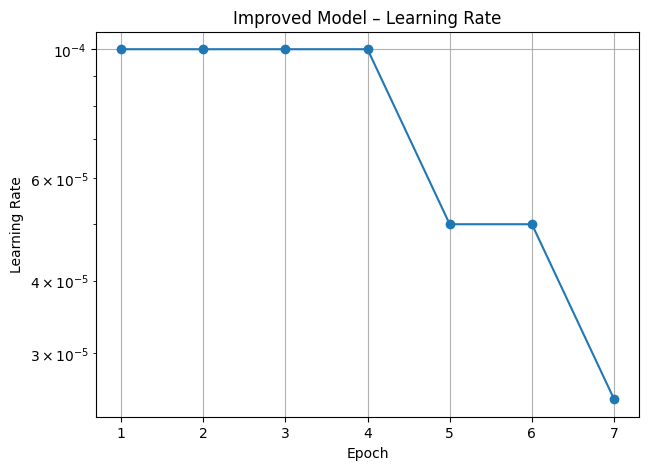

Accuracy     0.987467
Precision    0.988248
Recall       0.986667
F1           0.987457
dtype: float64


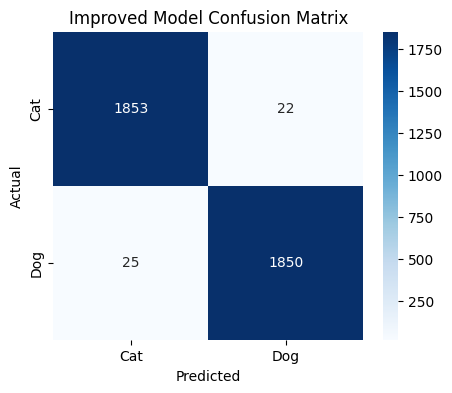


Classification report:
              precision    recall  f1-score   support

         Cat     0.9867    0.9883    0.9875      1875
         Dog     0.9882    0.9867    0.9875      1875

    accuracy                         0.9875      3750
   macro avg     0.9875    0.9875    0.9875      3750
weighted avg     0.9875    0.9875    0.9875      3750



In [14]:
# Improved Model
improved = build_model(dropout=0.50)

# Make absolutely sure the complete model is on the T4 GPU
improved = improved.to(DEVICE)

print("Model device:", next(improved.parameters()).device)

improved, improved_history = train_model(
    improved,
    train_loader,
    val_loader,
    epochs=15,
    lr=1e-4,
    weight_decay=1e-4,
    patience=4
)

plot_history(improved_history, "Improved Model")

improved_metrics, improved_y, improved_pred = evaluate_model(
    improved, test_loader
)

print(pd.Series(improved_metrics))

plot_confusion(
    improved_y,
    improved_pred,
    "Improved Model Confusion Matrix"
)

print("\nClassification report:")
print(
    classification_report(
        improved_y,
        improved_pred,
        target_names=["Cat", "Dog"],
        digits=4
    )
)

plot_history(improved_history, "Improved Model")

improved_metrics, improved_y, improved_pred = evaluate_model(
    improved, test_loader
)
print(pd.Series(improved_metrics))
plot_confusion(improved_y, improved_pred, "Improved Model Confusion Matrix")

print("\nClassification report:")
print(
    classification_report(
        improved_y,
        improved_pred,
        target_names=["Cat", "Dog"],
        digits=4
    )
)


## 8. Experiment C – Dropout Comparison

The assignment asks us to discuss whether different dropout values were tried. We compare 0.30, 0.50 and 0.70.

To save time, this experiment can be run for a small number of epochs. The best setting should then be used for the final model.


In [17]:
dropout_results = []

for rate in [0.30, 0.50, 0.70]:
    print(f"\n===== Dropout {rate:.2f} =====")
    m = build_model(dropout=rate).to(DEVICE)

    m, h = train_model(
        m,
        train_loader,
        val_loader,
        epochs=6,
        lr=1e-4,
        weight_decay=1e-4,
        patience=2
    )

    metrics, _, _ = evaluate_model(m, val_loader)

    dropout_results.append({
        "Dropout": rate,
        "Validation Accuracy": metrics["Accuracy"],
        "Validation Precision": metrics["Precision"],
        "Validation Recall": metrics["Recall"],
        "Validation F1": metrics["F1"],
    })

dropout_df = pd.DataFrame(dropout_results)
dropout_df



===== Dropout 0.30 =====


/usr/local/lib/python3.13/dist-packages/PIL/TiffImagePlugin.py:950: UserWarning: Truncated File Read
  warnings.warn(str(msg))


Epoch 01/6 | train loss 0.0856 acc 0.9694 | val loss 0.0381 acc 0.9867 | lr 1.00e-04 | 132.4s


/usr/local/lib/python3.13/dist-packages/PIL/TiffImagePlugin.py:950: UserWarning: Truncated File Read
  warnings.warn(str(msg))


Epoch 02/6 | train loss 0.0478 acc 0.9831 | val loss 0.0314 acc 0.9904 | lr 1.00e-04 | 124.1s


...

Epoch 04/6 | train loss 0.0362 acc 0.9874 | val loss 0.0311 acc 0.9888 | lr 1.00e-04 | 121.0s


/usr/local/lib/python3.13/dist-packages/PIL/TiffImagePlugin.py:950: UserWarning: Truncated File Read
  warnings.warn(str(msg))


Epoch 05/6 | train loss 0.0246 acc 0.9915 | val loss 0.0366 acc 0.9856 | lr 5.00e-05 | 121.0s
Early stopping triggered.


/usr/local/lib/python3.13/dist-packages/PIL/TiffImagePlugin.py:950: UserWarning: Truncated File Read
  warnings.warn(str(msg))


,Dropout,Validation Accuracy,Validation Precision,Validation Recall,Validation F1
0,0.3,0.990400,0.989877,0.990933,0.990405
1,0.5,0.988000,0.983615,0.992533,0.988054
2,0.7,0.989333,0.988812,0.989867,0.989339


## 9. Final Results Table

This table compares the baseline and improved model. The numbers are generated automatically after training.


In [18]:
results = pd.DataFrame([
    {"Model": "Baseline", **baseline_metrics},
    {"Model": "Improved", **improved_metrics},
])

results


,Model,Accuracy,Precision,Recall,F1
0,Baseline,0.984533,0.982988,0.986133,0.984558
1,Improved,0.987467,0.988248,0.986667,0.987457


## 10. Overfitting / Underfitting Analysis

Use the generated curves to answer:
- Does training accuracy continue increasing while validation accuracy stops improving?
- Does validation loss start increasing while training loss decreases?
- Did the scheduler reduce the learning rate when validation loss plateaued?
- Did early stopping terminate unnecessary epochs?
- Did augmentation, BatchNorm, Dropout and weight decay reduce the train/validation gap?

Do not claim overfitting or underfitting unless the curves actually show it.


In [20]:
# Save the final model
MODEL_PATH = "cats_dogs_resnet18_final.pth"
torch.save(improved.state_dict(), MODEL_PATH)
print("Saved:", MODEL_PATH)

# Save results for the report
results.to_csv("model_results.csv", index=False)
dropout_df.to_csv("dropout_experiment.csv", index=False)
print("Saved model_results.csv and dropout_experiment.csv")


Saved: cats_dogs_resnet18_final.pth
Saved model_results.csv and dropout_experiment.csv


## 11. Report Notes

After running the notebook, transfer the actual results into the report.

### Proposed architecture
ResNet18 pretrained on ImageNet + custom classifier. The ResNet18 feature dimension is obtained programmatically with `model.fc.in_features`, so the architecture remains robust to the selected backbone.

### Regularization
- BatchNorm1d in the custom classifier
- Dropout
- Random horizontal flip
- Rotation
- Color jitter
- AdamW weight decay

### Optimization
- AdamW
- Initial learning rate: 1e-4
- Weight decay: 1e-4
- ReduceLROnPlateau: factor 0.5
- Early stopping patience: 4

### Activation functions
- ReLU in the hidden classifier layer
- Final layer outputs logits for two classes
- CrossEntropyLoss is used during training

### Important
Replace every discussion of performance with the actual values generated by the notebook. Do not use example numbers from tutorials or the internet as if they were your own results.
